# Bài tập ANN Homework

Mục tiêu: khảo sát ảnh hưởng của kiến trúc mạng ANN, loss function, optimizer và learning rate.

Dataset sử dụng: make_circles.

Đây là bài toán phân loại nhị phân phi tuyến.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)

# Chuẩn bị dữ liệu

Tạo dữ liệu hình tròn bằng `make_circles`.

Dữ liệu được chia thành:
- 80% train
- 20% test

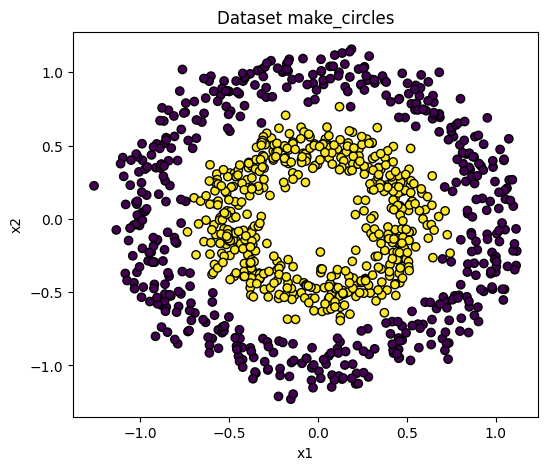

In [3]:
X, y = make_circles(
    n_samples=1000,
    noise=0.1,
    factor=0.5,
    random_state=42
)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.view(-1), edgecolors="k")
plt.title("Dataset make_circles")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Hàm train chung

Hàm `train()` dùng để huấn luyện model.

Hàm trả về:
- loss_history
- acc_history

In [4]:
def train(model, epochs=500, lr=0.01, optimizer_name="adam", loss_name="bce"):
    if loss_name == "bce":
        criterion = nn.BCELoss()
    else:
        criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        model.train()

        output = model(X_train)
        loss = criterion(output, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        model.eval()

        with torch.no_grad():
            test_output = model(X_test)

            if loss_name == "logits":
                pred = (torch.sigmoid(test_output) > 0.5).float()
            else:
                pred = (test_output > 0.5).float()

            acc = (pred == y_test).float().mean().item()
            acc_history.append(acc)

    return loss_history, acc_history

# Phần 1: Thay đổi cấu trúc ANN

So sánh 3 mô hình:

1. Mô hình gốc: 2 → 4 → 1
2. Mô hình tăng số nút ẩn: 2 → 8 → 1
3. Mô hình thêm một lớp ẩn: 2 → 8 → 6 → 1

Tất cả model train 500 epoch.

In [5]:
class ANN_4(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


class ANN_8(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


class ANN_8_6(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [6]:
model_4 = ANN_4()
model_8 = ANN_8()
model_8_6 = ANN_8_6()

loss_4, acc_4 = train(model_4, epochs=500, lr=0.01)
loss_8, acc_8 = train(model_8, epochs=500, lr=0.01)
loss_8_6, acc_8_6 = train(model_8_6, epochs=500, lr=0.01)

print("Mô hình 2-4-1")
print("Loss cuối:", loss_4[-1])
print("Test accuracy:", acc_4[-1])

print("\nMô hình 2-8-1")
print("Loss cuối:", loss_8[-1])
print("Test accuracy:", acc_8[-1])

print("\nMô hình 2-8-6-1")
print("Loss cuối:", loss_8_6[-1])
print("Test accuracy:", acc_8_6[-1])

Mô hình 2-4-1
Loss cuối: 0.5309622287750244
Test accuracy: 0.7099999785423279

Mô hình 2-8-1
Loss cuối: 0.026527652516961098
Test accuracy: 0.9800000190734863

Mô hình 2-8-6-1
Loss cuối: 0.026632191613316536
Test accuracy: 0.9750000238418579


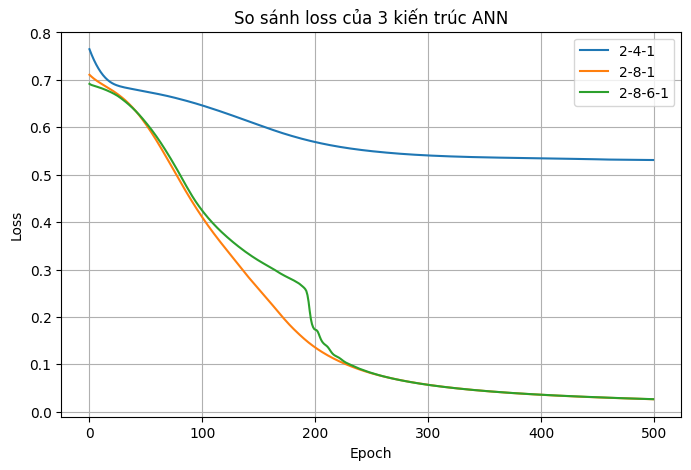

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(loss_4, label="2-4-1")
plt.plot(loss_8, label="2-8-1")
plt.plot(loss_8_6, label="2-8-6-1")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("So sánh loss của 3 kiến trúc ANN")
plt.legend()
plt.grid(True)
plt.show()

## Nhận xét phần 1

Mô hình có nhiều nút hơn thường giảm loss nhanh hơn vì có khả năng học biểu diễn phức tạp hơn.

Mô hình 8 nút thường tốt hơn mô hình 4 nút. Mô hình 8 + 6 nút có thể tốt hơn nữa, nhưng mức cải thiện không phải lúc nào cũng lớn.

Không thấy overfitting rõ nếu test accuracy vẫn cao và không giảm mạnh ở cuối quá trình train.

Có thể có diminishing returns. Khi tăng từ 4 nút lên 8 nút, kết quả thường cải thiện rõ hơn. Nhưng khi thêm tiếp lớp ẩn 6 nút, kết quả có thể không cải thiện nhiều tương ứng.

# Phần 2: Loss và Optimizer

Đổi `BCELoss` thành `BCEWithLogitsLoss`.

Với `BCEWithLogitsLoss`, model không dùng `Sigmoid` ở cuối.

Khi predict, dùng:

```python
torch.sigmoid(output) > 0.5

In [8]:

class ANN_Logits(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.net(x)


model_logits = ANN_Logits()

loss_logits, acc_logits = train(
    model_logits,
    epochs=500,
    lr=0.01,
    optimizer_name="adam",
    loss_name="logits"
)

print("BCEWithLogitsLoss")
print("Loss cuối:", loss_logits[-1])
print("Test accuracy:", acc_logits[-1])

BCEWithLogitsLoss
Loss cuối: 0.5363240838050842
Test accuracy: 0.7200000286102295


## Nhận xét BCEWithLogitsLoss

`BCEWithLogitsLoss` ổn định số học hơn `BCELoss`.

Nguyên nhân là vì `BCEWithLogitsLoss` gộp Sigmoid và Binary Cross Entropy vào cùng một hàm loss.

Cách này giúp hạn chế lỗi tràn số khi giá trị output quá lớn hoặc quá nhỏ.

## So sánh Adam và SGD

Đổi optimizer từ Adam sang SGD.

Thông số SGD:
- learning rate = 0.01
- momentum = 0.9

In [9]:
model_adam = ANN_4()

loss_adam, acc_adam = train(
    model_adam,
    epochs=500,
    lr=0.01,
    optimizer_name="adam",
    loss_name="bce"
)

model_sgd = ANN_4()

loss_sgd, acc_sgd = train(
    model_sgd,
    epochs=500,
    lr=0.01,
    optimizer_name="sgd",
    loss_name="bce"
)

print("Adam")
print("Loss cuối:", loss_adam[-1])
print("Test accuracy:", acc_adam[-1])

print("\nSGD")
print("Loss cuối:", loss_sgd[-1])
print("Test accuracy:", acc_sgd[-1])

Adam
Loss cuối: 0.08253102004528046
Test accuracy: 0.9350000023841858

SGD
Loss cuối: 0.6619349122047424
Test accuracy: 0.5


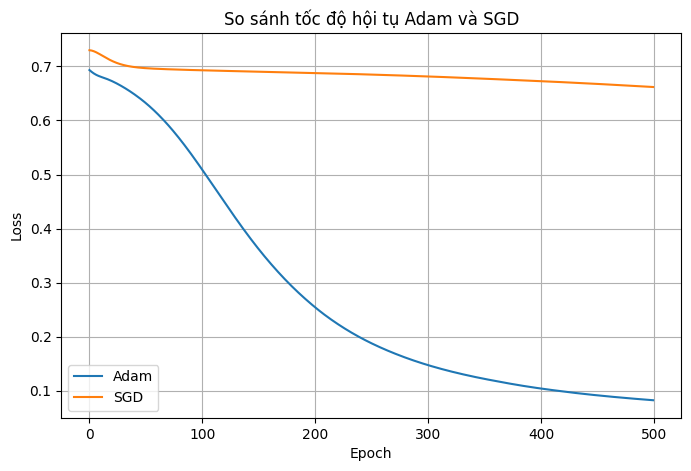

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(loss_adam, label="Adam")
plt.plot(loss_sgd, label="SGD")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("So sánh tốc độ hội tụ Adam và SGD")
plt.legend()
plt.grid(True)
plt.show()

## Nhận xét optimizer

Adam thường hội tụ nhanh hơn SGD vì Adam tự điều chỉnh tốc độ học cho từng tham số.

SGD với momentum vẫn học được, nhưng tốc độ giảm loss thường chậm hơn Adam.

# Phần 3: Phân tích learning rate

Thử 3 learning rate:

- 0.001
- 0.01
- 0.1

Dùng cấu trúc gốc: 2 → 4 → 1.

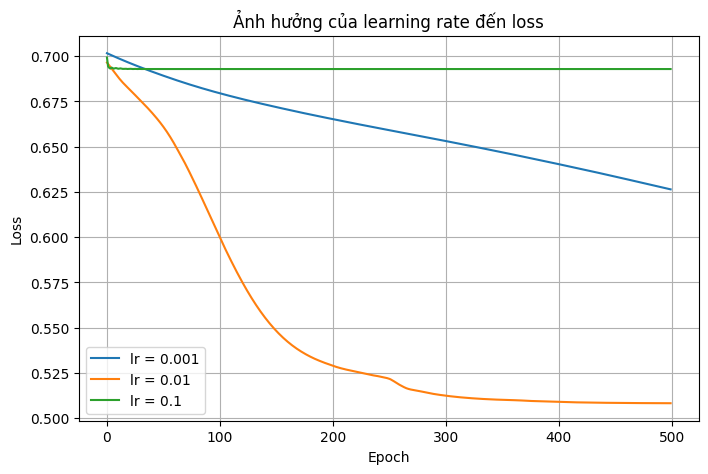

Learning rate = 0.001
Loss cuối: 0.6264122724533081
Test accuracy: 0.6650000214576721

Learning rate = 0.01
Loss cuối: 0.5082143545150757
Test accuracy: 0.6700000166893005

Learning rate = 0.1
Loss cuối: 0.6929075717926025
Test accuracy: 0.46000000834465027



In [11]:
learning_rates = [0.001, 0.01, 0.1]

loss_lr = {}
acc_lr = {}

for lr in learning_rates:
    model = ANN_4()

    loss_history, acc_history = train(
        model,
        epochs=500,
        lr=lr,
        optimizer_name="adam",
        loss_name="bce"
    )

    loss_lr[lr] = loss_history
    acc_lr[lr] = acc_history


plt.figure(figsize=(8, 5))

for lr in learning_rates:
    plt.plot(loss_lr[lr], label=f"lr = {lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ảnh hưởng của learning rate đến loss")
plt.legend()
plt.grid(True)
plt.show()


for lr in learning_rates:
    print(f"Learning rate = {lr}")
    print("Loss cuối:", loss_lr[lr][-1])
    print("Test accuracy:", acc_lr[lr][-1])
    print()

## Nhận xét learning rate

`lr = 0.001` thường học chậm vì mỗi lần cập nhật trọng số quá nhỏ.

`lr = 0.01` thường ổn định, loss giảm đều và dễ hội tụ.

`lr = 0.1` có thể học nhanh hơn nhưng dễ dao động. Nếu loss tăng mạnh hoặc không giảm thì learning rate quá lớn.

## Vẽ ranh giới quyết định

Vẽ decision boundary tại các epoch:

- 10
- 100
- 500

Boundary ban đầu còn đơn giản. Sau nhiều epoch, boundary sẽ cong dần theo dạng dữ liệu hình tròn.

In [12]:
def plot_decision_boundary(model, title, use_logits=False):
    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5
    y_min = X[:, 1].min() - 0.5
    y_max = X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    model.eval()

    with torch.no_grad():
        output = model(grid)

        if use_logits:
            pred = (torch.sigmoid(output) > 0.5).float()
        else:
            pred = (output > 0.5).float()

    pred = pred.numpy().reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, pred, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y.view(-1), edgecolors="k")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

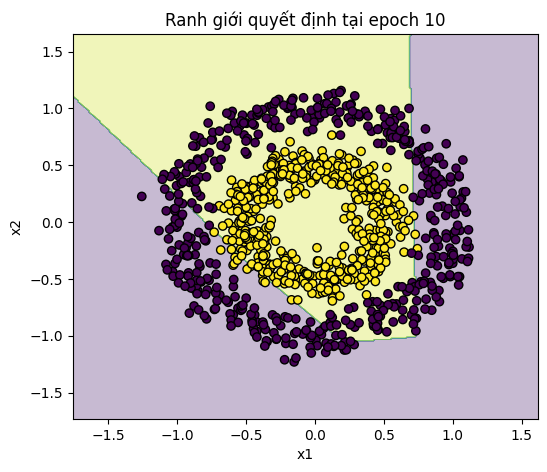

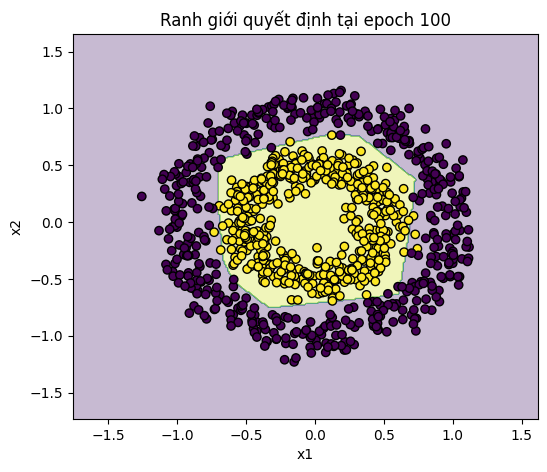

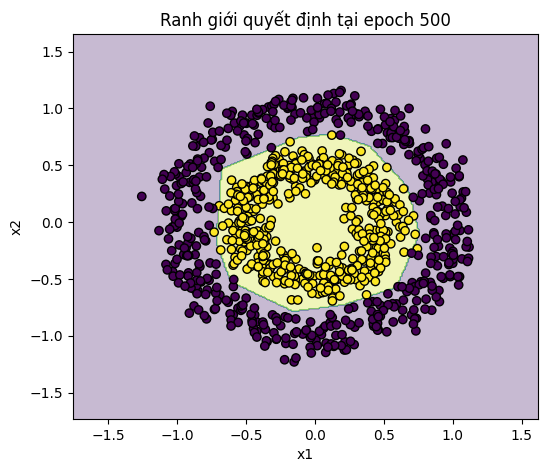

In [13]:
def train_save_models(epochs_list=[10, 100, 500]):
    model = ANN_8_6()

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    saved_models = {}

    for epoch in range(1, 501):
        model.train()

        output = model(X_train)
        loss = criterion(output, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch in epochs_list:
            saved_model = ANN_8_6()
            saved_model.load_state_dict(model.state_dict())
            saved_models[epoch] = saved_model

    return saved_models


saved_models = train_save_models()

for epoch in [10, 100, 500]:
    plot_decision_boundary(
        saved_models[epoch],
        f"Ranh giới quyết định tại epoch {epoch}"
    )

## Nhận xét decision boundary

Ở epoch 10, boundary còn đơn giản và phân tách chưa tốt.

Ở epoch 100, boundary bắt đầu cong theo dạng dữ liệu hình tròn.

Ở epoch 500, boundary rõ hơn và phân tách tốt hơn giữa lớp trong và lớp ngoài.